# Online Retail Business Intelligence Analysis

**Dataset:** Online Retail Dataset (UCI / Kaggle)

**Objective:**
Analyze sales transactions to uncover business insights, identify customer purchasing behavior, perform RFM segmentation, and prepare data for SQL and Power BI analysis.

---

## Notebook Structure

1. Import Libraries
2. Load Dataset
3. Initial Exploratory Data Analysis
4. Data Cleaning
5. Feature Engineering
6. Business Exploratory Data Analysis
7. Business Insights
8. RFM Customer Segmentation
9. Export Files

# Executive Summary

This project analyzes the Online Retail dataset to identify sales trends, customer purchasing behavior, and business performance.

The analysis includes:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- KPI calculation
- Customer segmentation using RFM analysis
- Data export for SQL and Power BI

The goal is to transform raw transactional data into meaningful business insights that support data-driven decision-making.

##  Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']     = 120
plt.rcParams['figure.figsize'] = (12, 5)


##  Load the Data

In [2]:
df = pd.read_csv("../DataSet/online_retail.csv")
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Initial Exploratory Data Analysis (Data Understanding)

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [4]:
df.describe()


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
print("Missing values:")
print(df.isnull().sum())


Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 5268


In [7]:
print("="*40)
print("Number of Rows :", len(df))
print("Number of Columns :", len(df.columns))
print("Unique Products :", df["StockCode"].nunique())
print("Unique Customers :", df["CustomerID"].nunique())
print("Countries :", df["Country"].nunique())
print("="*40)

Number of Rows : 541909
Number of Columns : 8
Unique Products : 4070
Unique Customers : 4372
Countries : 38


# Data Cleaning

The raw dataset contains duplicate records, cancelled invoices, invalid quantities, and invalid prices. These issues must be removed before performing any business analysis.

The following cleaning steps are applied:

1. Remove duplicate rows.
2. Remove cancelled invoices.
3. Remove negative or zero quantities.
4. Remove zero or negative prices.
5. Create new features for analysis.


In [8]:
df_clean = df.copy()

print("Original Shape:", df.shape)
print("Working Copy Shape:", df_clean.shape)

Original Shape: (541909, 8)
Working Copy Shape: (541909, 8)


In [9]:
# ==========================================
# Remove Duplicate Rows
# ==========================================

duplicates = df_clean.duplicated().sum()

print("Duplicate Rows:", duplicates)

df_clean.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates:", df_clean.shape)

Duplicate Rows: 5268
Shape After Removing Duplicates: (536641, 8)


In [10]:
# ==========================================
# Remove Cancelled Invoices
# ==========================================

cancelled = df_clean["InvoiceNo"].astype(str).str.startswith("C").sum()

print("Cancelled Invoices:", cancelled)

df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

print("Shape After Removing Cancellations:", df_clean.shape)

Cancelled Invoices: 9251
Shape After Removing Cancellations: (527390, 8)


In [11]:
# ==========================================
# Remove Invalid Quantities
# ==========================================

negative_qty = (df_clean["Quantity"] <= 0).sum()

print("Invalid Quantity Rows:", negative_qty)

df_clean = df_clean[df_clean["Quantity"] > 0]

print("Shape After Quantity Cleaning:", df_clean.shape)

Invalid Quantity Rows: 1336
Shape After Quantity Cleaning: (526054, 8)


In [12]:
# ==========================================
# Remove Invalid Prices
# ==========================================

invalid_price = (df_clean["UnitPrice"] <= 0).sum()

print("Invalid Price Rows:", invalid_price)

df_clean = df_clean[df_clean["UnitPrice"] > 0]

print("Shape After Price Cleaning:", df_clean.shape)

Invalid Price Rows: 1176
Shape After Price Cleaning: (524878, 8)


In [13]:
print("="*50)
print("Final Clean Dataset Shape")
print(df_clean.shape)
print("="*50)

Final Clean Dataset Shape
(524878, 8)


# Feature Engineering

In [14]:
df_clean["TotalSales"] = (
    df_clean["Quantity"] *
    df_clean["UnitPrice"]
)

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [15]:
# ==========================================
# Convert InvoiceDate
# ==========================================

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [16]:
# ==========================================
# Time Features
# ==========================================

df_clean["Year"] = df_clean["InvoiceDate"].dt.year

df_clean["Month"] = df_clean["InvoiceDate"].dt.month

df_clean["MonthName"] = df_clean["InvoiceDate"].dt.strftime("%b")

df_clean["DayOfWeek"] = df_clean["InvoiceDate"].dt.day_name()

df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour

In [17]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,MonthName,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,Dec,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Dec,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,Dec,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Dec,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Dec,Wednesday,8


In [18]:
print("=" * 60)
print("Final Dataset Information")
print("=" * 60)

print(f"Rows: {len(df_clean):,}")
print(f"Columns: {len(df_clean.columns)}")
print(f"Countries: {df_clean['Country'].nunique()}")
print(f"Products: {df_clean['StockCode'].nunique()}")
print(f"Customers: {df_clean['CustomerID'].nunique()}")

print("=" * 60)

Final Dataset Information
Rows: 524,878
Columns: 14
Countries: 38
Products: 3922
Customers: 4338


# Business Exploratory Data Analysis (EDA)

After cleaning and preparing the dataset, this section explores key business metrics and sales patterns.

The analysis focuses on:

- Revenue KPIs
- Monthly sales trend
- Product performance
- Country performance
- Sales by day of week

In [19]:
# ==========================================
# Business KPIs
# ==========================================

total_revenue = df_clean["TotalSales"].sum()

total_orders = df_clean["InvoiceNo"].nunique()

total_customers = df_clean["CustomerID"].nunique()

unique_products = df_clean["StockCode"].nunique()

countries = df_clean["Country"].nunique()

average_order_value = (
    df_clean.groupby("InvoiceNo")["TotalSales"]
    .sum()
    .mean()
)

In [20]:
print("=" * 50)
print("BUSINESS KPIs")
print("=" * 50)

print(f"Total Revenue      : £{total_revenue:,.2f}")
print(f"Total Orders       : {total_orders:,}")
print(f"Total Customers    : {total_customers:,}")
print(f"Unique Products    : {unique_products:,}")
print(f"Countries Served   : {countries}")
print(f"Average Order Value: £{average_order_value:,.2f}")

BUSINESS KPIs
Total Revenue      : £10,642,110.80
Total Orders       : 19,960
Total Customers    : 4,338
Unique Products    : 3,922
Countries Served   : 38
Average Order Value: £533.17


In [21]:
# ==========================================
# Monthly Revenue
# ==========================================

monthly_sales = (
    df_clean.groupby(["Year", "Month"])["TotalSales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Year,Month,TotalSales
0,2010,12,821452.730
1,2011,1,689811.610
2,2011,2,522545.560
3,2011,3,716215.260
4,2011,4,536968.491


In [22]:
monthly_sales["YearMonth"] = (
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str).str.zfill(2)
)

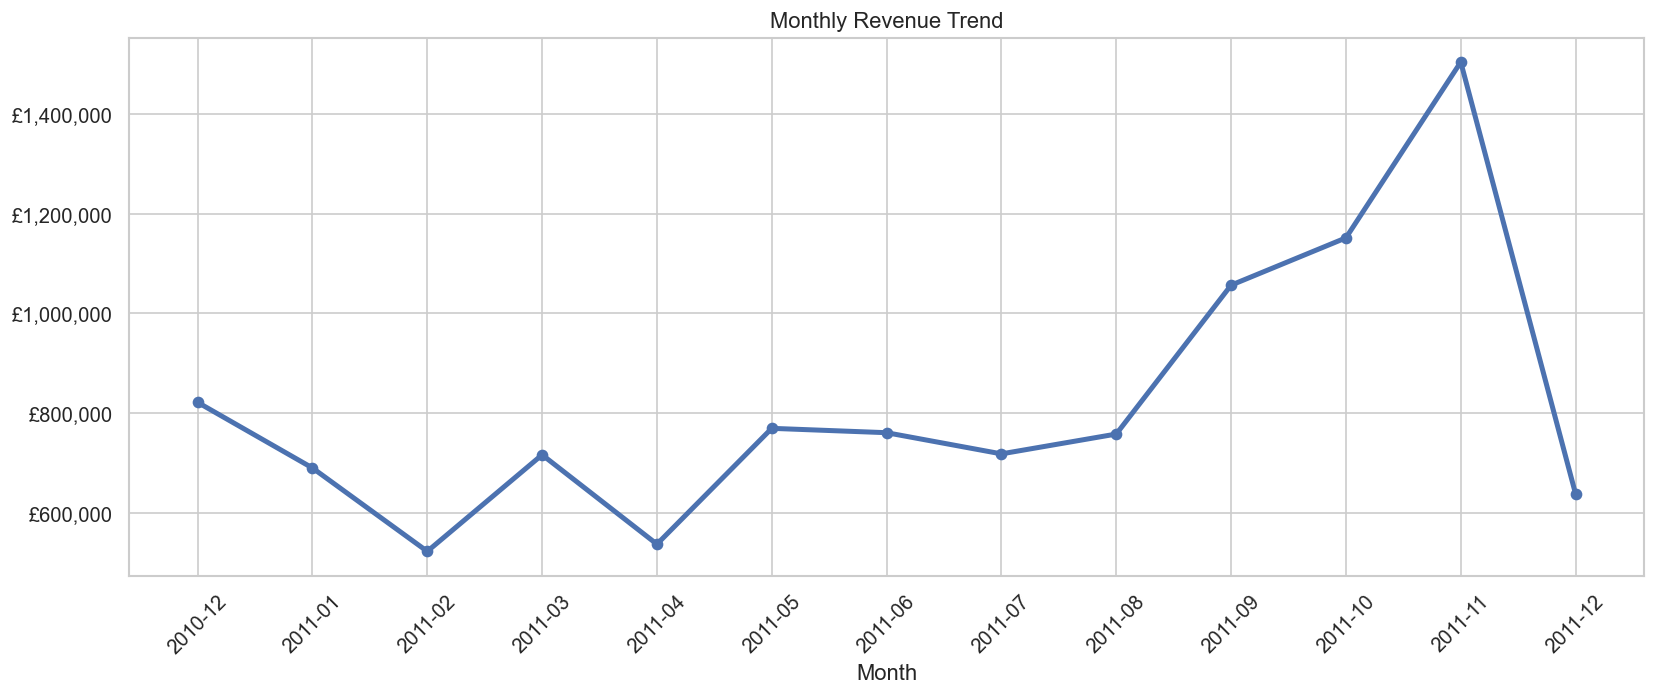

In [23]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["TotalSales"],
    marker="o",
    linewidth=3
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

import matplotlib.ticker as mtick

ax = plt.gca()
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

plt.tight_layout()

plt.show()

In [24]:
peak_month = monthly_sales.loc[
    monthly_sales["TotalSales"].idxmax()
]

lowest_month = monthly_sales.loc[
    monthly_sales["TotalSales"].idxmin()
]

print(f"Highest Revenue Month : {peak_month['YearMonth']}")
print(f"Revenue               : £{peak_month['TotalSales']:,.2f}")

print()

print(f"Lowest Revenue Month  : {lowest_month['YearMonth']}")
print(f"Revenue               : £{lowest_month['TotalSales']:,.2f}")

Highest Revenue Month : 2011-11
Revenue               : £1,503,866.78

Lowest Revenue Month  : 2011-02
Revenue               : £522,545.56


In [25]:
# ==========================================
# Top 10 Products by Revenue
# ==========================================

non_product_items = ["DOTCOM POSTAGE", "POSTAGE", "Manual"]

top_products = (
    df_clean[~df_clean["Description"].isin(non_product_items)]
    .groupby("Description")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

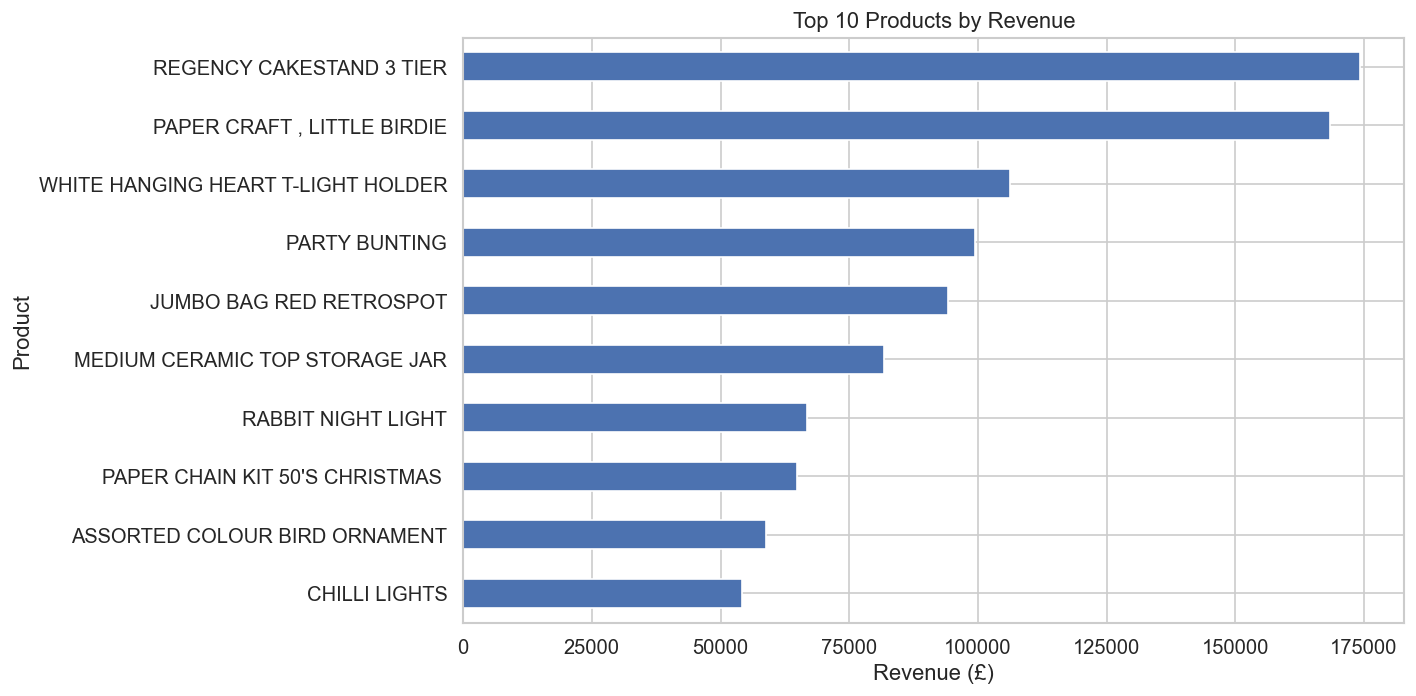

In [26]:
plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")

plt.xlabel("Revenue (£)")

plt.ylabel("Product")

plt.tight_layout()

plt.show()

In [27]:
# ==========================================
# Revenue by Country
# ==========================================

country_sales = (
    df_clean.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

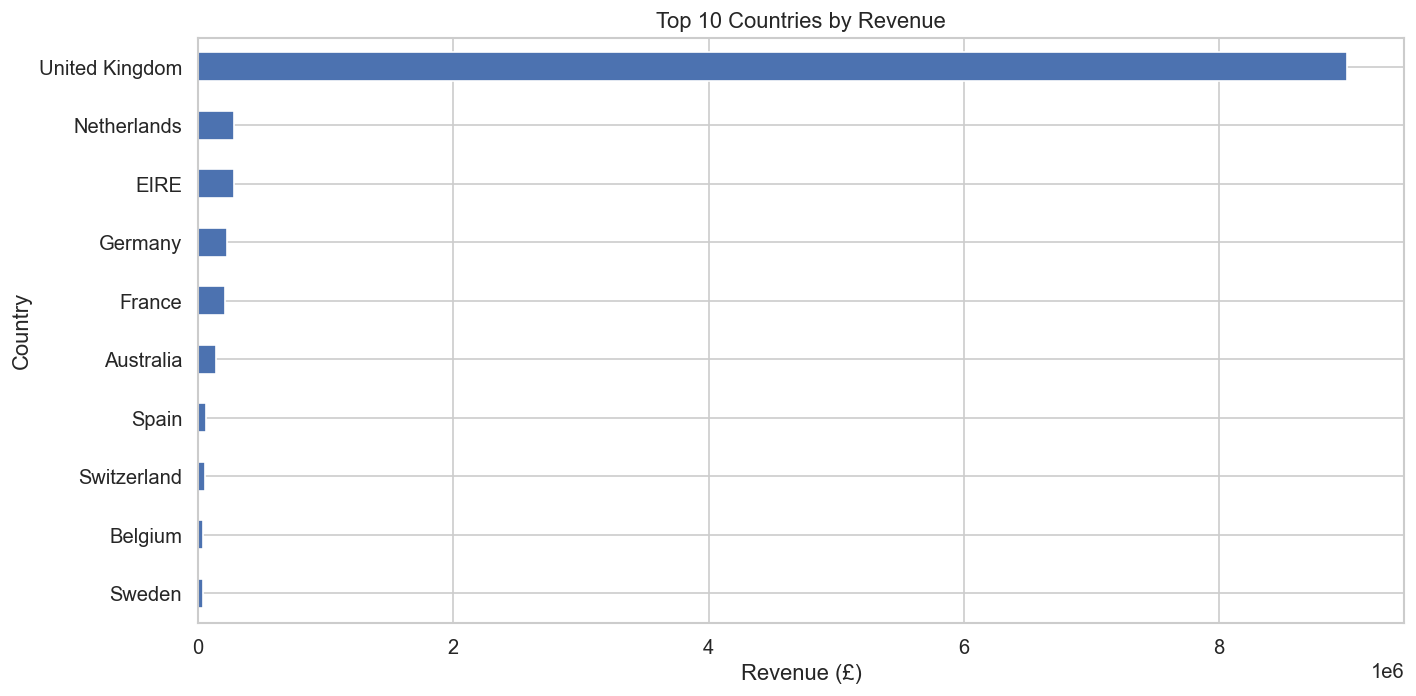

In [28]:
plt.figure(figsize=(12,6))

country_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Revenue (£)")

plt.tight_layout()

plt.show()

In [29]:
# ==========================================
# Top 10 Products by Quantity Sold
# ==========================================

non_product_items = ["DOTCOM POSTAGE", "POSTAGE", "Manual"]

top_quantity = (
    df_clean[~df_clean["Description"].isin(non_product_items)]
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

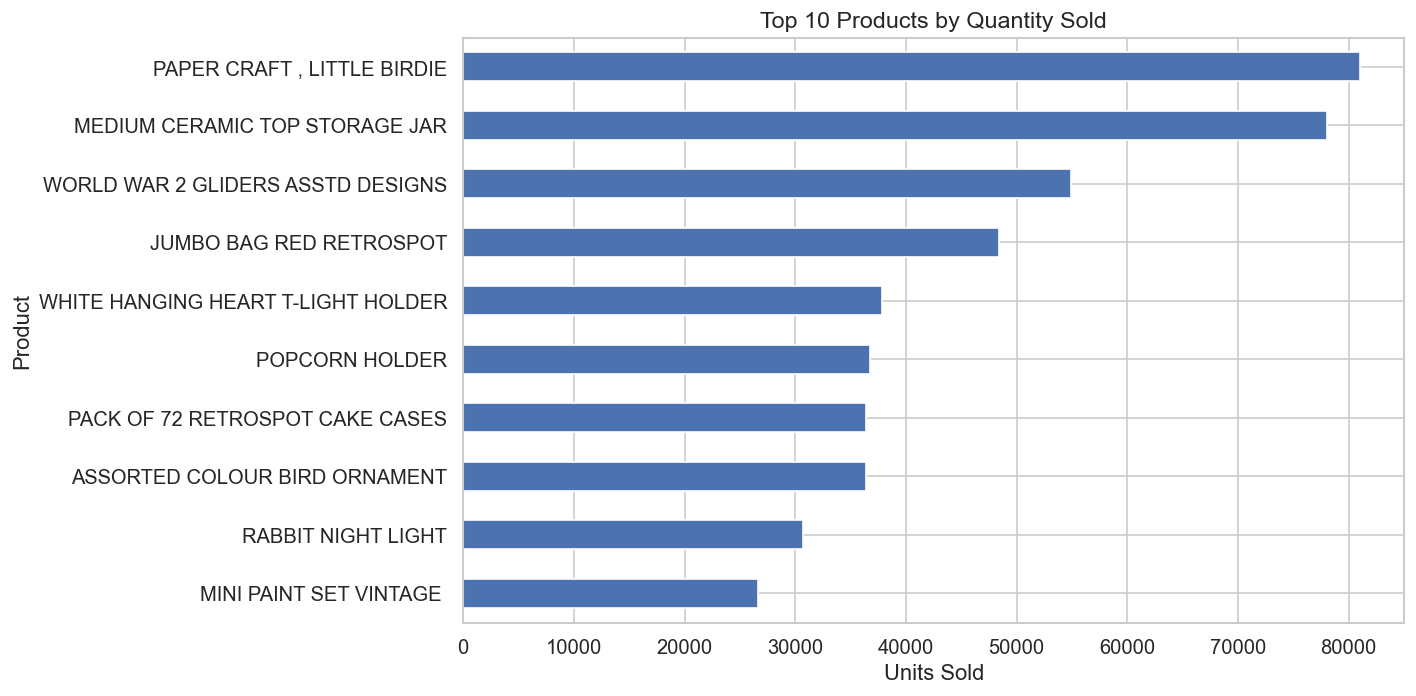

In [30]:
plt.figure(figsize=(12,6))

top_quantity.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold", fontsize=14)

plt.xlabel("Units Sold")

plt.ylabel("Product")

plt.tight_layout()

plt.show()

In [31]:
# Revenue by Day of Week
day_sales = (
    df_clean.groupby("DayOfWeek")["TotalSales"]
    .sum()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_sales = day_sales.reindex(day_order)

In [32]:
# ==========================================
# Top 10 Customers by Revenue
# ==========================================

top_customers = (
    df_clean[df_clean["CustomerID"].notna()]
    .groupby("CustomerID")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.to_frame(name="Revenue")

,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


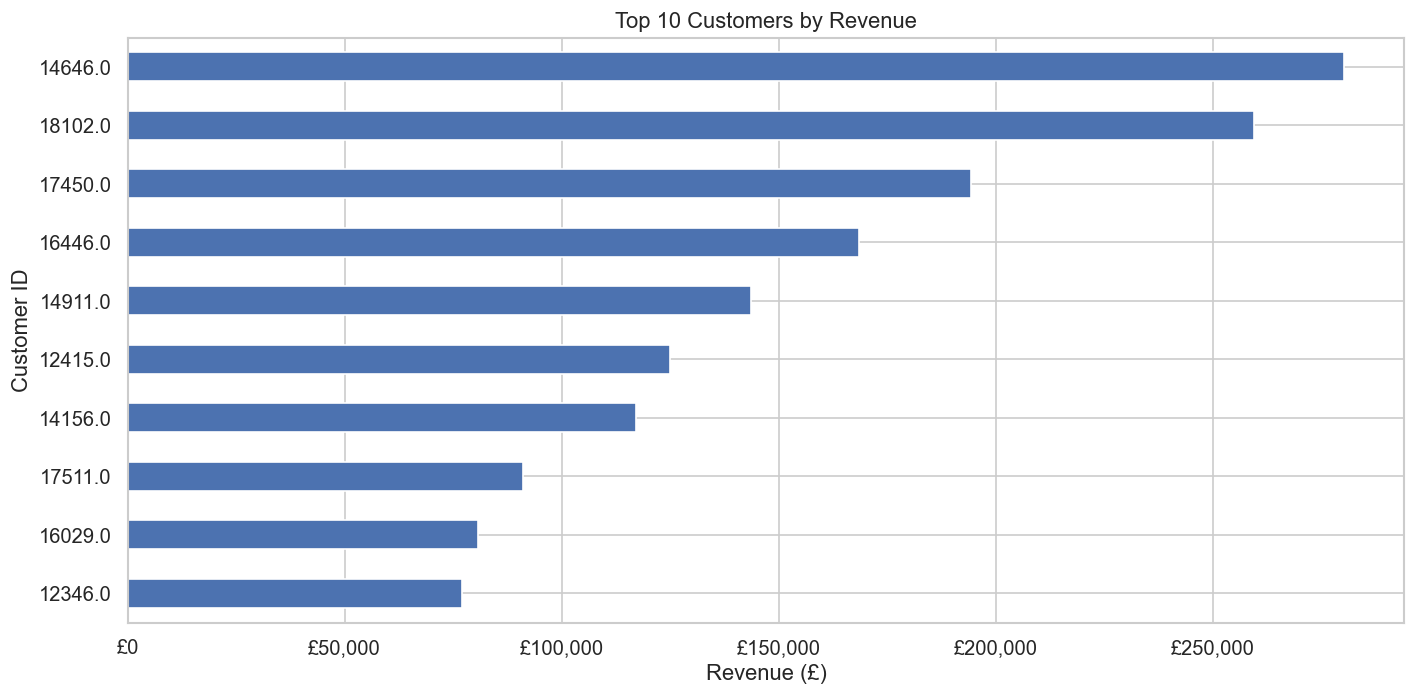

In [33]:
plt.figure(figsize=(12,6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")

plt.xlabel("Revenue (£)")

plt.ylabel("Customer ID")

ax = plt.gca()
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

plt.tight_layout()
plt.show()

In [34]:
summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Countries",
        "Products"
    ],
    "Value": [
        f"£{total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"£{average_order_value:,.2f}",
        countries,
        unique_products
    ]
})

summary

,Metric,Value
0,Total Revenue,"£10,642,110.80"
1,Total Orders,"19,960"
2,Total Customers,"4,338"
3,Average Order Value,£533.17
4,Countries,38
5,Products,3922


# Business Insights

Based on the exploratory analysis, the following insights were identified:

- Revenue peaks during the holiday season, with November generating the highest sales.
- The United Kingdom contributes the majority of revenue, while the Netherlands, Germany, France, and Ireland are the strongest international markets.
- A small number of products generate a large share of total revenue.
- Most orders are relatively small, while a limited number of high-value transactions increase the average order value.

# RFM Customer Segmentation

RFM (**R**ecency, **F**requency, **M**onetary) is a customer segmentation technique that scores every customer on three behavioural dimensions:

- **Recency** — Number of days since the customer's last purchase (snapshot date − last invoice date). Lower is better.
- **Frequency** — Number of distinct orders (invoices) placed by the customer. Higher is better.
- **Monetary** — Total revenue generated by the customer. Higher is better.

**1–5 scoring.** Each metric is split into 5 quantile-based groups (quintiles) using `pd.qcut`, so each score bucket contains roughly the same number of customers. A score of `5` always means "best" and `1` always means "worst":
- `RecencyScore`: most-recent buyers get `5`, least-recent buyers get `1` (labels are reversed since a *smaller* Recency value is *better*).
- `FrequencyScore`: most-frequent buyers get `5`, least-frequent buyers get `1`.
- `MonetaryScore`: highest spenders get `5`, lowest spenders get `1`.

**AVG(Frequency, Monetary).** In addition to the individual scores, an `AvgF_M` value is calculated as the average of `FrequencyScore` and `MonetaryScore`, rounded **up** to the nearest whole number (1–5). Rounding up (rather than standard rounding) is the convention used by the segmentation table for this project, so a customer with `FrequencyScore=3` and `MonetaryScore=4` (average 3.5) is treated as `AvgF_M=4`.

**Segmentation table.** Each customer is assigned to a named segment by looking up their `(RecencyScore, AvgF_M)` pair in the segmentation table supplied for this project (Champions, Potential Loyalists, Loyal Customers, Recent Customers, Promising, Customers Needing Attention, At Risk, Can Lose Them, Hibernating, Lost). If a `(RecencyScore, AvgF_M)` combination occurs in the data but is not listed in the table, that customer is labelled `"Other"` as a documented fallback — this is checked automatically below.

**What the segments mean (business interpretation):**
- **Champions** — bought recently, buy often, spend the most: your best customers.
- **Potential Loyalists** — recent customers with moderate frequency/spend who could be nurtured into loyal customers.
- **Loyal Customers** — consistent, above-average buyers who are not necessarily brand new.
- **Recent Customers** — bought very recently but with low frequency/spend so far (new or one-off buyers).
- **Promising** — fairly recent buyers with low frequency/spend; worth engaging early.
- **Customers Needing Attention** — average recency/frequency/spend; at risk of drifting away without a nudge.
- **At Risk** — used to buy frequently/spend a lot but haven't purchased in a while.
- **Can Lose Them** — historically high-value customers who have gone quiet; high-priority win-back targets.
- **Hibernating** — low recency, frequency and spend; largely inactive.
- **Lost** — lowest recency, frequency and spend across the board.

In [35]:
# ==========================================
# Build RFM Table
# ==========================================

rfm_df = df_clean[df_clean["CustomerID"].notna()].copy()

snapshot_date = rfm_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    rfm_df.groupby("CustomerID")
    .agg({
        "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
        "InvoiceNo": "nunique",
        "TotalSales": "sum"
    })
)

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [36]:
rfm.describe().round(2)

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


In [37]:
# ==========================================
# RFM Scores (1-5 scale)
# ==========================================
# Each metric is split into 5 quantile-based groups (quintiles) using
# pd.qcut, so a score of 5 always means "best" and 1 always means "worst".
#
# - RecencyScore   : customers who purchased MORE recently get a HIGHER
#                    score, so the quintile labels are reversed
#                    (5 = most recent, 1 = least recent).
# - FrequencyScore : customers who purchase MORE often get a HIGHER score.
#                    .rank(method="first") breaks ties so qcut can create
#                    5 equally-sized bins.
# - MonetaryScore  : customers who spend MORE get a HIGHER score.

rfm["RecencyScore"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
).astype(int)

rfm["FrequencyScore"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

rfm["MonetaryScore"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
).astype(int)

rfm.head()

,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,5
12347.0,2,7,4310.00,5,5,5
12348.0,75,4,1797.24,2,4,4
12349.0,19,1,1757.55,4,1,4
12350.0,310,1,334.40,1,1,2


In [38]:
# ==========================================
# RFM Score String + AVG(Frequency, Monetary)
# ==========================================
# RFM_Score : concatenated R-F-M scores, useful as a quick per-customer
#             fingerprint (e.g. "545" = RecencyScore 5, FrequencyScore 4,
#             MonetaryScore 5).
# AvgF_M    : average of FrequencyScore and MonetaryScore, rounded UP to
#             the nearest whole number (1-5) so it can be matched against
#             the segmentation table, which only defines whole-number
#             Recency / AVG(F,M) combinations. Because FrequencyScore and
#             MonetaryScore are each integers from 1-5, their sum is
#             between 2 and 10, and "(sum + 1) // 2" is an exact integer
#             formula for ceil(sum / 2) -- e.g. an average of 3.5 becomes
#             4, while an average that is already a whole number (e.g. 3)
#             stays unchanged.

rfm["RFM_Score"] = (
    rfm["RecencyScore"].astype(str)
    + rfm["FrequencyScore"].astype(str)
    + rfm["MonetaryScore"].astype(str)
)

rfm["AvgF_M"] = (rfm["FrequencyScore"] + rfm["MonetaryScore"] + 1) // 2

rfm.head()

,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_Score,AvgF_M
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,3
12347.0,2,7,4310.00,5,5,5,555,5
12348.0,75,4,1797.24,2,4,4,244,4
12349.0,19,1,1757.55,4,1,4,414,3
12350.0,310,1,334.40,1,1,2,112,2


In [39]:
# ==========================================
# Customer Segmentation
# ==========================================
# Customers are grouped using RecencyScore and AvgF_M according to the
# segmentation table provided for this project. Every (RecencyScore,
# AvgF_M) combination explicitly listed in the table maps to its named
# segment below.

segment_map = {
    # Champions
    (5, 5): "Champions",
    (5, 4): "Champions",
    (4, 5): "Champions",

    # Potential Loyalists
    (5, 2): "Potential Loyalists",
    (4, 2): "Potential Loyalists",
    (3, 3): "Potential Loyalists",
    (4, 3): "Potential Loyalists",

    # Loyal Customers
    (5, 3): "Loyal Customers",
    (4, 4): "Loyal Customers",
    (3, 5): "Loyal Customers",
    (3, 4): "Loyal Customers",

    # Recent Customers
    (5, 1): "Recent Customers",

    # Promising
    (4, 1): "Promising",
    (3, 1): "Promising",

    # Customers Needing Attention
    (3, 2): "Customers Needing Attention",
    (2, 3): "Customers Needing Attention",
    (2, 2): "Customers Needing Attention",

    # At Risk
    (2, 5): "At Risk",
    (2, 4): "At Risk",
    (1, 3): "At Risk",

    # Can Lose Them
    (1, 5): "Can Lose Them",
    (1, 4): "Can Lose Them",

    # Hibernating
    (1, 2): "Hibernating",

    # Lost
    (1, 1): "Lost",
}

def segment_customer(row):
    """Look up (RecencyScore, AvgF_M) in the segmentation table.
    Combinations that are NOT covered by the table (if any occur in the
    data) fall back to "Other" -- see the coverage check printed below."""
    key = (row["RecencyScore"], row["AvgF_M"])
    return segment_map.get(key, "Other")

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

# ------------------------------------------------------------------
# Coverage check: does every (RecencyScore, AvgF_M) pair that actually
# occurs in this dataset have a defined segment in segment_map?
# ------------------------------------------------------------------
observed_keys = set(zip(rfm["RecencyScore"], rfm["AvgF_M"]))
unmapped_keys = sorted(k for k in observed_keys if k not in segment_map)

if unmapped_keys:
    print("Combinations not covered by the segmentation table (mapped to 'Other'):")
    for r_score, fm_score in unmapped_keys:
        n = ((rfm["RecencyScore"] == r_score) & (rfm["AvgF_M"] == fm_score)).sum()
        print(f"  RecencyScore={r_score}, AvgF_M={fm_score}  ->  {n} customers")
else:
    print("Every (RecencyScore, AvgF_M) combination present in the data is covered")
    print("by the segmentation table -- no 'Other' segment was needed.")

rfm.head()

Combinations not covered by the segmentation table (mapped to 'Other'):
  RecencyScore=2, AvgF_M=1  ->  81 customers


,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_Score,AvgF_M,Segment
CustomerID,,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,3,At Risk
12347.0,2,7,4310.00,5,5,5,555,5,Champions
12348.0,75,4,1797.24,2,4,4,244,4,At Risk
12349.0,19,1,1757.55,4,1,4,414,3,Potential Loyalists
12350.0,310,1,334.40,1,1,2,112,2,Hibernating


In [40]:
# ==========================================
# Segment Validation
# ==========================================
# Confirms the segmentation is complete and internally consistent before
# it is summarised, charted and exported below.

segment_counts = rfm["Segment"].value_counts()
segment_pct = (segment_counts / len(rfm) * 100).round(2)

segment_validation = pd.DataFrame({
    "CustomerCount": segment_counts,
    "PercentOfCustomers": segment_pct
}).sort_values("CustomerCount", ascending=False)

print("Segment distribution (count and % of customers):")
display(segment_validation)

# Every customer must have exactly one, non-null segment label.
assert rfm["Segment"].notna().all(), "Some customers are missing a Segment value."
assert rfm["Segment"].apply(lambda s: isinstance(s, str)).all(), "Segment values must be text labels."

# Segment counts must sum to the total number of RFM customers.
assert int(segment_counts.sum()) == len(rfm), "Segment counts do not sum to the total number of customers."

print(
    f"\nValidation passed: {len(rfm):,} customers, each assigned to exactly one "
    f"of {rfm['Segment'].nunique()} segments."
)

Segment distribution (count and % of customers):


,CustomerCount,PercentOfCustomers
Segment,,
Champions,940,21.67
Loyal Customers,740,17.06
Customers Needing Attention,729,16.80
Potential Loyalists,578,13.32
At Risk,444,10.24
Hibernating,424,9.77
Lost,183,4.22
Promising,122,2.81
Other,81,1.87



Validation passed: 4,338 customers, each assigned to exactly one of 11 segments.


In [41]:
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        CustomerCount=("Segment", "count"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean")
    )
    .round(2)
    .sort_values("CustomerCount", ascending=False)
)

segment_summary

,CustomerCount,AvgRecency,AvgFrequency,AvgMonetary
Segment,,,,
Champions,940,11.00,11.19,6277.69
Loyal Customers,740,33.80,4.30,1717.52
Customers Needing Attention,729,97.99,1.50,460.25
Potential Loyalists,578,31.96,1.83,522.47
At Risk,444,167.18,3.36,1549.03
Hibernating,424,274.68,1.09,288.07
Lost,183,286.46,1.00,144.31
Promising,122,39.96,1.00,156.38
Other,81,123.98,1.00,135.19


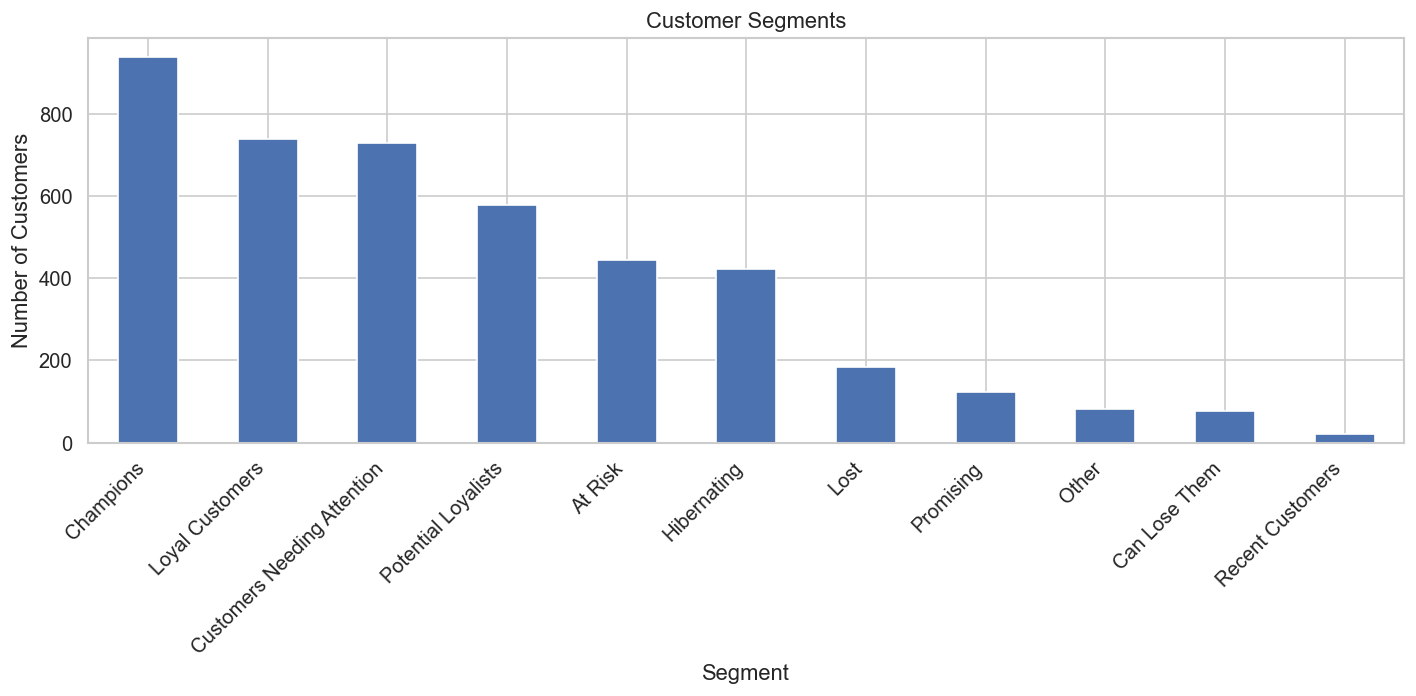

In [42]:
plt.figure(figsize=(12,6))

rfm["Segment"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segments")

plt.xlabel("Segment")

plt.ylabel("Number of Customers")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [43]:
rfm_segment = rfm.reset_index()[["CustomerID", "Segment"]]

segment_sales = (
    df_clean.merge(
        rfm_segment,
        on="CustomerID",
        how="left"
    )
)

In [44]:
segment_revenue = (
    segment_sales.groupby("Segment")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

Segment
Champions                      5901026.070
Loyal Customers                1270964.981
At Risk                         687767.980
Customers Needing Attention     335520.432
Potential Loyalists             301988.250
Can Lose Them                   207700.081
Hibernating                     122140.600
Lost                             26408.940
Promising                        19078.050
Other                            10950.380
Recent Customers                  3663.130
Name: TotalSales, dtype: float64

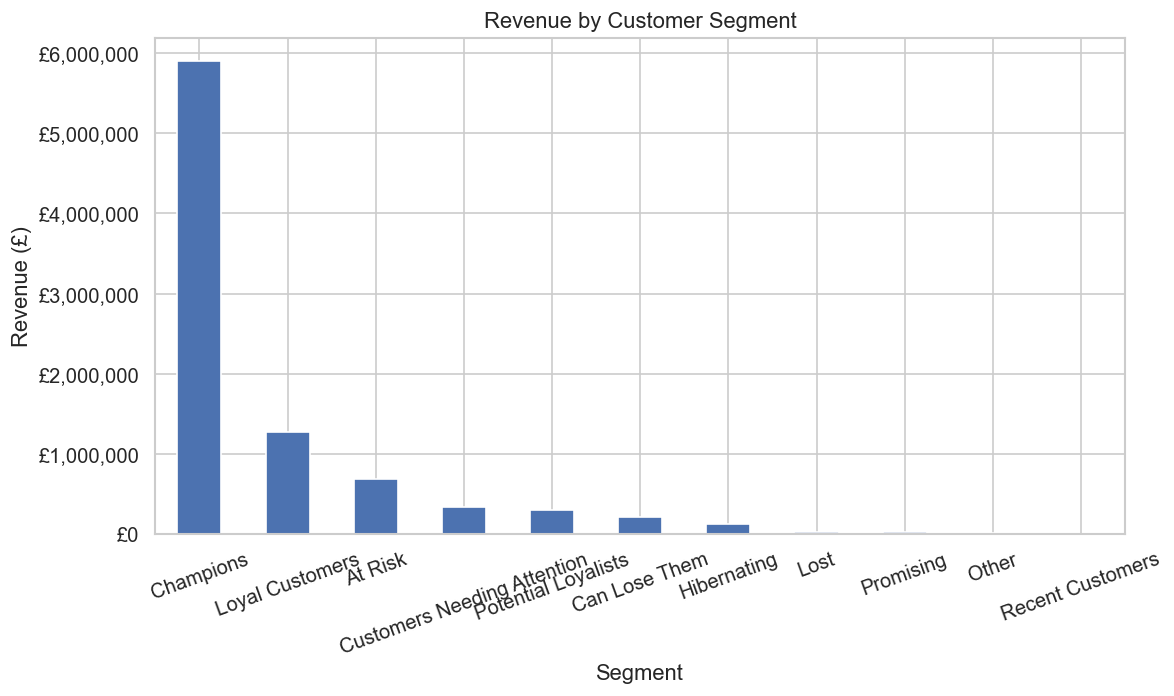

In [45]:
plt.figure(figsize=(10,6))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")

plt.ylabel("Revenue (£)")

ax = plt.gca()
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

# RFM Analysis Insights

The RFM analysis, using the project's Recency / AVG(Frequency, Monetary) segmentation table, provides a detailed view of customer behaviour across ten named segments (plus an "Other" fallback only if an uncovered score combination occurs in the data).

Key observations:

- **Champions** are the most valuable customers: they buy recently, frequently, and spend the most. They should be rewarded and used for referrals/reviews.
- **Loyal Customers** and **Potential Loyalists** contribute consistently to revenue and are strong candidates for loyalty programs and upsell campaigns.
- **Recent Customers** and **Promising** buyers are early in their journey — nurturing them with onboarding offers can convert them into loyal customers.
- **Customers Needing Attention** show average engagement and risk drifting away without a re-engagement nudge.
- **At Risk** and **Can Lose Them** customers were previously high-value but have gone quiet; they are high-priority win-back targets, especially "Can Lose Them" given their historically strong frequency/monetary scores.
- **Hibernating** and **Lost** customers show the lowest recency, frequency and monetary scores and represent the lowest-priority segment for active marketing spend.

# Export RFM Segments

In [46]:
rfm.to_csv("../DataSet/rfm/rfm_segments.csv", index=True)

print(f"Saved: rfm_segments.csv  ({len(rfm):,} customers)")

Saved: rfm_segments.csv  (4,338 customers)


##  Export Cleaned Data

In [47]:
df_clean.to_csv("../DataSet/cleaned_data.csv", index=False)
print(f"Saved: cleaned_data.csv ({len(df_clean):,} rows)")

Saved: cleaned_data.csv (524,878 rows)
